# Section 0: Environment Setup

This section installs the required dependencies, checks for GPU availability, sets deterministic seeds for reproducibility, and defines a global configuration dictionary.  The code also mounts Google Drive to ensure that outputs are persistently stored.

In [9]:

# Install dependencies if they are missing.  Import modules to check versions.
import importlib, subprocess, sys, os, random, json

# Define the packages needed for this pipeline.  These are installed only if not already present.
packages = [
    "mediapipe",
    "ultralytics",
    "opencv-python-headless",
    "numpy",
    "pandas",
    "plotly",
    "scipy",
    "pillow",
    "pytesseract",
    "scikit-image",
    "tqdm"
]
for pkg in packages:
    try:
        importlib.import_module(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Version checks and GPU availability
import mediapipe as mp
import cv2
import numpy as np
import pandas as pd
import torch
import plotly
import scipy
from PIL import Image

print("MediaPipe version:", mp.__version__)
print("Ultralytics version:", importlib.import_module('ultralytics').__version__)
print("OpenCV version:", cv2.__version__)
print("PyTorch CUDA available:", torch.cuda.is_available())

# Deterministic seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if hasattr(torch, 'manual_seed'):
    torch.manual_seed(SEED)

# Global configuration dictionary
CONFIG = {
    "fps_target": 120,
    "frame_resize": (640, 360),
    "hand_conf_thresh": 0.5,
    "ball_conf_thresh": 0.25,
    "smoothing_window": 7,
    "output_dir": "/content/drive/MyDrive/pitch_analysis_output",
    "ocr_enabled": False,
    "quick_test_frames": 150
}

# Ensure the output directory exists
os.makedirs(CONFIG["output_dir"], exist_ok=True)

# Mount Google Drive for persistent storage
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print("Google Drive could not be mounted. Running in local mode:", e)


MediaPipe version: 0.10.32
Ultralytics version: 8.4.12
OpenCV version: 4.13.0
PyTorch CUDA available: False
Google Drive could not be mounted. Running in local mode: Error: credential propagation was unsuccessful


# Section 1: Data Ingestion

This section handles interactive video upload, extracts basic metadata such as frames per second (fps), resolution, and duration, and provides utilities for sampling frames with stride control.  An optional optical character recognition (OCR) routine can parse on‑screen pitch metrics, though it is disabled by default.

In [10]:

from google.colab import files
import cv2
import numpy as np
import pandas as pd
import os
import pytesseract
from PIL import Image
from typing import List, Tuple, Dict


def upload_videos() -> Dict[str, str]:
    """Upload video files using the Colab file picker and save them locally."""
    uploaded = files.upload()
    video_paths: Dict[str, str] = {}
    for name, data in uploaded.items():
        path = os.path.join('/content', name)
        with open(path, 'wb') as f:
            f.write(data)
        video_paths[name] = path
    return video_paths


def extract_metadata(video_path: str) -> Dict[str, float]:
    """Return metadata including fps, width, height, duration, and frame count."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = frame_count / fps if fps > 0 else 0
    cap.release()
    return {
        "fps": fps,
        "width": width,
        "height": height,
        "duration_sec": duration,
        "frame_count": int(frame_count)
    }


def sample_frames(video_path: str, stride: int = 30, resize: Tuple[int, int] = None, max_frames: int = 150) -> List[np.ndarray]:
    """Extract frames from a video at regular intervals.  Optionally resize frames and limit the total number extracted."""
    frames: List[np.ndarray] = []
    cap = cv2.VideoCapture(video_path)
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % stride == 0:
            if resize:
                frame = cv2.resize(frame, resize)
            frames.append(frame)
            if len(frames) >= max_frames:
                break
        idx += 1
    cap.release()
    return frames


def save_sample_frames(frames: List[np.ndarray], prefix: str, out_dir: str) -> None:
    """Save sampled frames into a QA directory for quick inspection."""
    qa_dir = os.path.join(out_dir, f"{prefix}_qa_frames")
    os.makedirs(qa_dir, exist_ok=True)
    for i, frame in enumerate(frames):
        cv2.imwrite(os.path.join(qa_dir, f"frame_{i:04d}.jpg"), frame)


def parse_ocr_overlay(frame: np.ndarray) -> Dict[str, str]:
    """Perform OCR on a single frame if OCR is enabled in the global config."""
    if not CONFIG.get("ocr_enabled", False):
        return {}
    text = pytesseract.image_to_string(Image.fromarray(frame))
    return {"overlay_text": text.strip()}

# Upload videos
VIDEO_PATHS = upload_videos()
print("Uploaded videos:", VIDEO_PATHS)

# Extract and display metadata
VIDEO_METADATA = {name: extract_metadata(path) for name, path in VIDEO_PATHS.items()}
print(pd.DataFrame(VIDEO_METADATA).T)


Saving 96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3.mov to 96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov
Uploaded videos: {'96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov': '/content/96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov'}
                                               fps   width  height  \
96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov  30.0  1120.0   672.0   

                                              duration_sec  frame_count  
96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov           7.5        225.0  


# Section 2: Hand Landmark Pipeline

Use MediaPipe's hand landmarker to detect the throwing hand in each frame.  Finger tip landmarks (thumb, index, middle, ring, pinky) are tracked, smoothed using a moving average, and exported to CSV and JSON.  A QA video overlay visualises the detected landmarks.

In [11]:
import os
import urllib.request
from typing import Dict, List, Tuple, Optional, Any

import cv2
import numpy as np
import pandas as pd
import mediapipe as mp

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision


def ensure_hand_model(model_path: str = "hand_landmarker.task") -> str:
    """
    Ensure a MediaPipe Hand Landmarker task model exists locally.

    Tries multiple known model URLs and validates file size before accepting.
    Returns the local model path if successful.
    Raises RuntimeError if all sources fail.
    """
    if os.path.exists(model_path) and os.path.getsize(model_path) > 100_000:
        print(f"[HandModel] Using cached model: {model_path}")
        return model_path

    candidate_urls: List[str] = [
        # Current docs "latest" style
        "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task",
        # Version-pinned
        "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
        # Legacy fallback used in older issue threads/examples
        "https://storage.googleapis.com/mediapipe-assets/hand_landmarker.task",
    ]

    last_error: Optional[Exception] = None
    for url in candidate_urls:
        try:
            tmp_path = model_path + ".tmp"
            print(f"[HandModel] Trying: {url}")
            urllib.request.urlretrieve(url, tmp_path)
            size = os.path.getsize(tmp_path)
            if size < 100_000:
                raise RuntimeError(f"Downloaded file is too small ({size} bytes).")
            os.replace(tmp_path, model_path)
            print(f"[HandModel] Downloaded model to {model_path} ({size} bytes)")
            return model_path
        except Exception as e:
            last_error = e
            print(f"[HandModel] Failed from {url}: {e}")
            try:
                if os.path.exists(tmp_path):
                    os.remove(tmp_path)
            except Exception:
                pass

    raise RuntimeError(
        "Could not download a valid hand_landmarker.task model from any known URL."
    ) from last_error


class HandLandmarkPipeline:
    """
    Hand landmark pipeline with robust fallback:
      1) MediaPipe Tasks HandLandmarker (preferred),
      2) MediaPipe Solutions Hands (fallback if model/tasks init fails).
    """

    def __init__(self, config: Dict[str, Any]):
        self.config = config
        self.smoothing_window = int(self.config.get("smoothing_window", 7))
        self.backend = "tasks"
        self.landmarker = None
        self.solutions_hands = None

        try:
            self.model_path = ensure_hand_model("hand_landmarker.task")
            options = mp_vision.HandLandmarkerOptions(
                base_options=mp_python.BaseOptions(model_asset_path=self.model_path),
                running_mode=mp_vision.RunningMode.IMAGE,
                num_hands=1,
                min_hand_detection_confidence=float(self.config.get("hand_conf_thresh", 0.5)),
                min_hand_presence_confidence=float(self.config.get("hand_conf_thresh", 0.5)),
                min_tracking_confidence=float(self.config.get("hand_conf_thresh", 0.5)),
            )
            self.landmarker = mp_vision.HandLandmarker.create_from_options(options)
            print("[HandPipeline] Initialized MediaPipe Tasks HandLandmarker.")
        except Exception as e:
            print(f"[HandPipeline] Tasks init failed: {e}")
            print("[HandPipeline] Falling back to mediapipe.solutions.hands")
            self.backend = "solutions"
            self.solutions_hands = mp.solutions.hands.Hands(
                static_image_mode=False,
                max_num_hands=1,
                min_detection_confidence=float(self.config.get("hand_conf_thresh", 0.5)),
                min_tracking_confidence=float(self.config.get("hand_conf_thresh", 0.5)),
                model_complexity=1,
            )

    @staticmethod
    def _extract_handedness_tasks(result: Any) -> str:
        """Parse handedness safely across MediaPipe versions."""
        try:
            h = result.handedness[0]
            # some versions: list[list[Category]]
            if isinstance(h, list) and len(h) > 0:
                h = h[0]
            if hasattr(h, "category_name") and h.category_name:
                return str(h.category_name)
            if hasattr(h, "display_name") and h.display_name:
                return str(h.display_name)
        except Exception:
            pass
        return "Unknown"

    def _detect_landmarks_tasks(
        self, rgb_frame: np.ndarray
    ) -> Tuple[Optional[List[Any]], str]:
        """Run MediaPipe Tasks detection for one RGB frame."""
        try:
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            result = self.landmarker.detect(mp_image)
            if result and result.hand_landmarks:
                return result.hand_landmarks[0], self._extract_handedness_tasks(result)
        except Exception:
            pass
        return None, "Unknown"

    def _detect_landmarks_solutions(
        self, rgb_frame: np.ndarray
    ) -> Tuple[Optional[List[Any]], str]:
        """Run MediaPipe Solutions fallback detection for one RGB frame."""
        try:
            result = self.solutions_hands.process(rgb_frame)
            if result and result.multi_hand_landmarks:
                hand_lm = result.multi_hand_landmarks[0].landmark
                handedness = "Unknown"
                if result.multi_handedness and len(result.multi_handedness) > 0:
                    cls = result.multi_handedness[0].classification[0]
                    handedness = str(getattr(cls, "label", "Unknown"))
                return hand_lm, handedness
        except Exception:
            pass
        return None, "Unknown"

    def process_video(self, video_path: str, quick_test: bool = False) -> Tuple[pd.DataFrame, str]:
        """
        Extract fingertip landmarks per frame, smooth trajectories, and export:
          - CSV
          - JSON
          - QA overlay video
        """
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"Cannot open video: {video_path}")

        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = float(cap.get(cv2.CAP_PROP_FPS) or 30.0)

        resize = self.config.get("frame_resize", None)
        out_w = int(resize[0]) if resize else width
        out_h = int(resize[1]) if resize else height

        os.makedirs(self.config["output_dir"], exist_ok=True)
        overlay_path = os.path.join(
            self.config["output_dir"],
            os.path.basename(video_path) + "_hand_overlay.mp4",
        )
        writer = cv2.VideoWriter(
            overlay_path,
            cv2.VideoWriter_fourcc(*"mp4v"),
            fps,
            (out_w, out_h),
        )

        finger_keys = ["thumb_tip", "index_tip", "middle_tip", "ring_tip", "pinky_tip"]
        lm_idx_map = {"thumb_tip": 4, "index_tip": 8, "middle_tip": 12, "ring_tip": 16, "pinky_tip": 20}
        smoothing_buffers: Dict[str, List[Tuple[float, float]]] = {k: [] for k in finger_keys}

        rows: List[Dict[str, Any]] = []
        frame_idx = 0
        max_frames = int(self.config.get("quick_test_frames", 150)) if quick_test else None

        while True:
            ret, frame_bgr = cap.read()
            if not ret:
                break

            if resize:
                frame_bgr = cv2.resize(frame_bgr, (out_w, out_h), interpolation=cv2.INTER_AREA)

            rgb_frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

            if self.backend == "tasks":
                hand_lm, handedness = self._detect_landmarks_tasks(rgb_frame)
            else:
                hand_lm, handedness = self._detect_landmarks_solutions(rgb_frame)

            row: Dict[str, Any] = {"frame": frame_idx, "handedness": handedness, "backend": self.backend}
            for fk in finger_keys:
                row[f"{fk}_x"] = None
                row[f"{fk}_y"] = None
                row[f"{fk}_conf"] = 0.0
                row[f"{fk}_x_smooth"] = None
                row[f"{fk}_y_smooth"] = None

            if hand_lm is not None:
                for fk, idx in lm_idx_map.items():
                    lm = hand_lm[idx]
                    x_px = float(lm.x * out_w)
                    y_px = float(lm.y * out_h)

                    row[f"{fk}_x"] = x_px
                    row[f"{fk}_y"] = y_px
                    row[f"{fk}_conf"] = 1.0  # explicit proxy confidence

                    smoothing_buffers[fk].append((x_px, y_px))
                    if len(smoothing_buffers[fk]) > self.smoothing_window:
                        smoothing_buffers[fk].pop(0)

                    xs = [p[0] for p in smoothing_buffers[fk]]
                    ys = [p[1] for p in smoothing_buffers[fk]]
                    row[f"{fk}_x_smooth"] = float(np.mean(xs))
                    row[f"{fk}_y_smooth"] = float(np.mean(ys))
            else:
                for fk in finger_keys:
                    vals = smoothing_buffers[fk]
                    xs = [p[0] for p in vals if p[0] is not None]
                    ys = [p[1] for p in vals if p[1] is not None]
                    row[f"{fk}_x_smooth"] = float(np.mean(xs)) if xs else None
                    row[f"{fk}_y_smooth"] = float(np.mean(ys)) if ys else None

            rows.append(row)

            # Overlay
            overlay = frame_bgr.copy()
            color_map = {
                "thumb_tip": (255, 0, 0),
                "index_tip": (0, 255, 0),
                "middle_tip": (0, 0, 255),
                "ring_tip": (255, 255, 0),
                "pinky_tip": (255, 0, 255),
            }
            for fk in finger_keys:
                x_s = row[f"{fk}_x_smooth"]
                y_s = row[f"{fk}_y_smooth"]
                if x_s is not None and y_s is not None:
                    color = color_map[fk]
                    cv2.circle(overlay, (int(x_s), int(y_s)), 4, color, -1)
                    cv2.putText(
                        overlay, fk.split("_")[0],
                        (int(x_s) + 6, int(y_s) - 6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA
                    )

            cv2.putText(
                overlay,
                f"Frame: {frame_idx} | backend: {self.backend}",
                (10, 22),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2,
                cv2.LINE_AA,
            )
            writer.write(overlay)

            frame_idx += 1
            if max_frames is not None and frame_idx >= max_frames:
                break

        cap.release()
        writer.release()

        df = pd.DataFrame(rows)
        base = os.path.basename(video_path)
        csv_path = os.path.join(self.config["output_dir"], f"{base}_hand_landmarks.csv")
        json_path = os.path.join(self.config["output_dir"], f"{base}_hand_landmarks.json")
        df.to_csv(csv_path, index=False)
        df.to_json(json_path, orient="records", indent=2)

        print(f"[HandPipeline] Complete: {video_path}")
        print(f"[HandPipeline] CSV: {csv_path}")
        print(f"[HandPipeline] JSON: {json_path}")
        print(f"[HandPipeline] Overlay: {overlay_path}")

        return df, overlay_path


# Run hand landmark extraction on uploaded videos
hand_pipelines: Dict[str, HandLandmarkPipeline] = {}
hand_results: Dict[str, Dict[str, Any]] = {}

for name, path in VIDEO_PATHS.items():
    pipeline = HandLandmarkPipeline(CONFIG)
    hand_pipelines[name] = pipeline
    df, overlay = pipeline.process_video(path, quick_test=True)
    hand_results[name] = {"df": df, "overlay_path": overlay}

print("Section 2 finished successfully.")
for k, v in hand_results.items():
    print(f"{k}: {len(v['df'])} frames processed | overlay -> {v['overlay_path']}")


[HandModel] Using cached model: hand_landmarker.task
[HandPipeline] Initialized MediaPipe Tasks HandLandmarker.
[HandPipeline] Complete: /content/96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov
[HandPipeline] CSV: /content/drive/MyDrive/pitch_analysis_output/96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov_hand_landmarks.csv
[HandPipeline] JSON: /content/drive/MyDrive/pitch_analysis_output/96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov_hand_landmarks.json
[HandPipeline] Overlay: /content/drive/MyDrive/pitch_analysis_output/96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov_hand_overlay.mp4
Section 2 finished successfully.
96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov: 150 frames processed | overlay -> /content/drive/MyDrive/pitch_analysis_output/96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov_hand_overlay.mp4


# Section 3: Ball Detection and Tracking

Detect and track the baseball using Ultralytics YOLO.  If YOLO misses the ball, a fallback based on OpenCV's Hough circle transform attempts to locate the ball. The result is a DataFrame recording ball centre, radius, and confidence per frame, along with a QA overlay video showing the tracked trajectory.

In [12]:

import os
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
from typing import Tuple, Dict, List

class BallTracker:
    """Detect and track a baseball using YOLO with a Hough circle fallback."""
    def __init__(self, config: Dict):
        self.config = config
        self.model = YOLO('yolov8n.pt')
        self.class_id = 32  # sports ball in COCO
        self.conf_thres = config.get('ball_conf_thresh', 0.25)
        self.frame_resize = config.get('frame_resize', None)
        self.output_dir = config.get('output_dir', '.')

    def detect_hough(self, gray: np.ndarray):
        circles = cv2.HoughCircles(
            gray,
            cv2.HOUGH_GRADIENT,
            dp=1.2,
            minDist=20,
            param1=50,
            param2=30,
            minRadius=5,
            maxRadius=50
        )
        if circles is not None:
            circles = np.round(circles[0, :]).astype('int')
            return circles[0]
        return None

    def process_video(self, video_path: str, quick_test: bool = False) -> Tuple[pd.DataFrame, str]:
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        resize = self.frame_resize
        out_w, out_h = (resize if resize else (width, height))
        overlay_path = os.path.join(self.output_dir, os.path.basename(video_path) + '_ball_overlay.mp4')
        writer = cv2.VideoWriter(overlay_path, cv2.VideoWriter_fourcc(*'mp4v'), fps or 30.0, (out_w, out_h))
        rows: List[Dict] = []
        trail_points: List[Tuple[int,int]] = []
        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame_resized = cv2.resize(frame, (out_w, out_h)) if resize else frame.copy()
            results = self.model(frame_resized, verbose=False)
            detections = results[0].boxes if results and len(results) > 0 else None
            ball_x = ball_y = ball_r = None
            ball_conf = 0.0
            if detections is not None and len(detections) > 0:
                for det in detections:
                    if int(det.cls[0]) == self.class_id and float(det.conf[0]) >= self.conf_thres:
                        x1, y1, x2, y2 = det.xyxy[0].cpu().numpy()
                        ball_x = (x1 + x2) / 2
                        ball_y = (y1 + y2) / 2
                        ball_r = max((x2 - x1), (y2 - y1)) / 2
                        ball_conf = float(det.conf[0])
                        break
            if ball_x is None:
                gray = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2GRAY)
                gray = cv2.medianBlur(gray, 5)
                circle = self.detect_hough(gray)
                if circle is not None:
                    ball_x, ball_y, ball_r = circle
                    ball_conf = 0.5
            rows.append({
                'frame': frame_idx,
                'ball_x': float(ball_x) if ball_x is not None else None,
                'ball_y': float(ball_y) if ball_y is not None else None,
                'ball_r': float(ball_r) if ball_r is not None else None,
                'ball_conf': ball_conf
            })
            overlay = frame_resized.copy()
            if ball_x is not None and ball_y is not None and ball_r is not None:
                center = (int(ball_x), int(ball_y))
                radius = int(ball_r)
                cv2.circle(overlay, center, radius, (0, 0, 255), 2)
                trail_points.append(center)
            for i in range(1, len(trail_points)):
                if trail_points[i-1] and trail_points[i]:
                    cv2.line(overlay, trail_points[i-1], trail_points[i], (255, 0, 0), 2)
            writer.write(overlay)
            frame_idx += 1
            if quick_test and frame_idx >= self.config.get('quick_test_frames', 150):
                break
        cap.release()
        writer.release()
        df = pd.DataFrame(rows)
        csv_path = os.path.join(self.output_dir, os.path.basename(video_path) + '_ball_tracking.csv')
        df.to_csv(csv_path, index=False)
        json_path = os.path.join(self.output_dir, os.path.basename(video_path) + '_ball_tracking.json')
        df.to_json(json_path, orient='records', indent=2)
        print(f"Ball tracking complete. CSV saved to {csv_path}")
        return df, overlay_path

# Run ball tracking on uploaded videos
ball_trackers = {}
ball_results = {}
for name, path in VIDEO_PATHS.items():
    tracker = BallTracker(CONFIG)
    ball_trackers[name] = tracker
    df, overlay = tracker.process_video(path, quick_test=True)
    ball_results[name] = {'df': df, 'overlay_path': overlay}


Ball tracking complete. CSV saved to /content/drive/MyDrive/pitch_analysis_output/96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov_ball_tracking.csv


**Section 3B**

In [13]:
# =========================
# PATCH A — BALL TRACK SANITIZER (run after Section 3)
# =========================
import os
import numpy as np
import pandas as pd
from typing import Dict

def sanitize_ball_track(
    ball_df: pd.DataFrame,
    frame_w: int,
    frame_h: int,
    hud_x_frac: float = 0.22,
    hud_y_frac: float = 0.25,
    r_min: float = 6.0,
    r_max: float = 45.0,
    reacquire_after: int = 3,
    step_frac_diag: float = 0.13
) -> pd.DataFrame:
    """
    Remove HUD-like false positives and impossible trajectory jumps.
    Keeps a 'track_valid' flag and interpolates only tiny gaps.
    """
    df = ball_df.copy().sort_values("frame").reset_index(drop=True)
    diag = float(np.hypot(frame_w, frame_h))
    max_step = step_frac_diag * diag

    df["ball_x_raw"] = df["ball_x"]
    df["ball_y_raw"] = df["ball_y"]
    df["ball_r_raw"] = df["ball_r"]
    df["ball_conf_raw"] = df["ball_conf"]

    hud_xmax = hud_x_frac * frame_w
    hud_ymax = hud_y_frac * frame_h

    raw_valid = (
        df["ball_x"].notna()
        & df["ball_y"].notna()
        & df["ball_r"].notna()
        & df["ball_r"].between(r_min, r_max)
        & ~((df["ball_x"] <= hud_xmax) & (df["ball_y"] <= hud_ymax))
    )

    track_valid = np.zeros(len(df), dtype=bool)
    last_x, last_y = np.nan, np.nan
    misses = 0

    for i, row in df.iterrows():
        if not raw_valid.iat[i]:
            misses += 1
            if misses >= reacquire_after:
                last_x, last_y = np.nan, np.nan
            continue

        x = float(row["ball_x"])
        y = float(row["ball_y"])

        if np.isnan(last_x):
            track_valid[i] = True
            last_x, last_y = x, y
            misses = 0
            continue

        step = float(np.hypot(x - last_x, y - last_y))
        if step <= max_step:
            track_valid[i] = True
            last_x, last_y = x, y
            misses = 0
        else:
            misses += 1
            if misses >= reacquire_after:
                last_x, last_y = np.nan, np.nan

    df["track_valid"] = track_valid

    for c in ["ball_x", "ball_y", "ball_r", "ball_conf"]:
        df.loc[~df["track_valid"], c] = np.nan

    # fill only short gaps
    df[["ball_x", "ball_y", "ball_r"]] = df[["ball_x", "ball_y", "ball_r"]].interpolate(
        limit=2, limit_direction="both"
    )

    return df

# apply sanitizer for each video
for name in VIDEO_PATHS:
    meta = VIDEO_METADATA[name]
    if CONFIG.get("frame_resize") is not None:
        frame_w, frame_h = CONFIG["frame_resize"]
    else:
        frame_w, frame_h = int(meta["width"]), int(meta["height"])

    clean_df = sanitize_ball_track(ball_results[name]["df"], frame_w=frame_w, frame_h=frame_h)
    ball_results[name]["df_clean"] = clean_df

    out_csv = os.path.join(CONFIG["output_dir"], f"{name}_ball_tracking_clean.csv")
    out_json = os.path.join(CONFIG["output_dir"], f"{name}_ball_tracking_clean.json")
    clean_df.to_csv(out_csv, index=False)
    clean_df.to_json(out_json, orient="records", indent=2)

    hud_like_pct = float(
        ((ball_results[name]["df"]["ball_x"].between(55,70)) &
         (ball_results[name]["df"]["ball_y"].between(50,60)) &
         (ball_results[name]["df"]["ball_r"].between(20,26))).mean()
    )
    print(f"[{name}] raw HUD-like detections: {hud_like_pct:.1%}")
    print(f"[{name}] clean valid rate: {clean_df['track_valid'].mean():.1%}")


[96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov] raw HUD-like detections: 71.3%
[96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov] clean valid rate: 27.3%


# Section 4: Release Window Detection

Estimate when the ball leaves the hand by analysing both the distance between the index finger and ball centre and the ball's acceleration.  Frames with the highest combined score are selected as candidate release moments.  A montage of these frames is saved for visual inspection.


[Release v3] 96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov: [16, 17, 19, 20]


,frame,dist,speed,acc,contact,contact_break,away,release_score
16,16,3.496800,0.000000,0.000000,True,False,0.0,8.520961e-01
17,17,13.351509,445.982062,13379.461873,True,False,0.0,4.352723e-01
19,19,15.714536,798.811617,10584.886648,True,False,0.0,3.353236e-01
20,20,23.642383,127.279221,-20145.971902,True,False,0.0,4.229692e-08


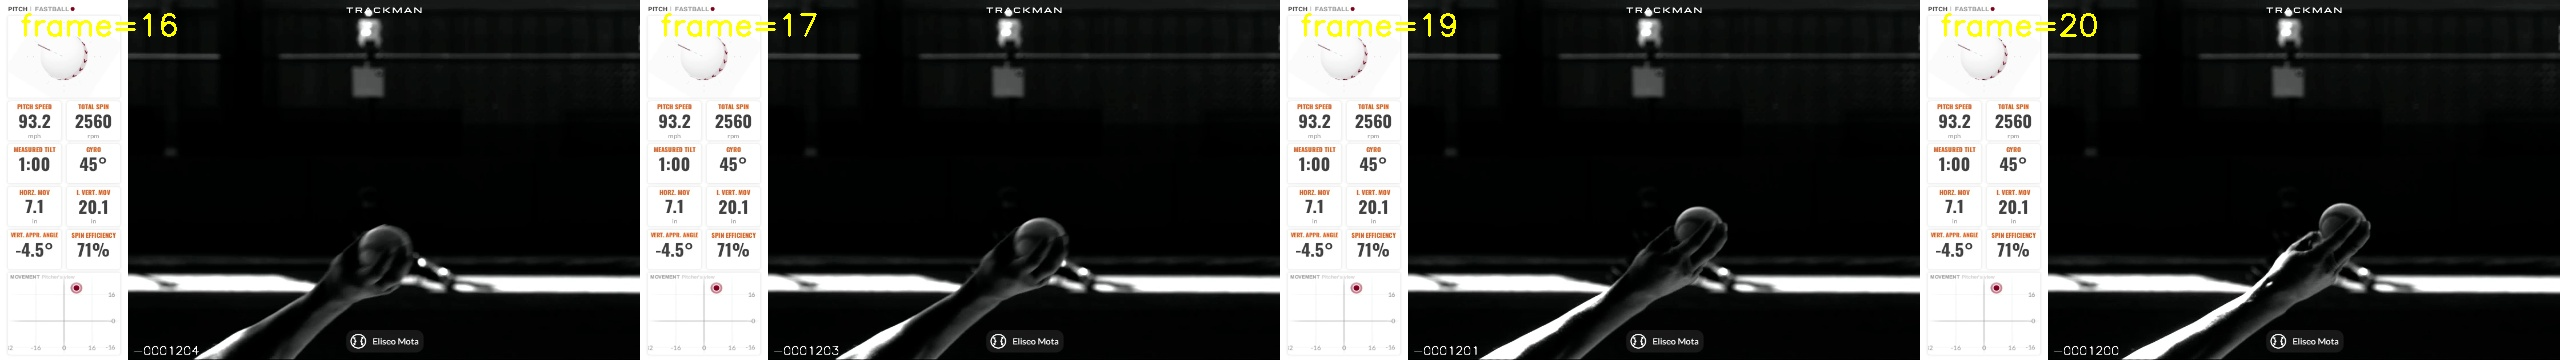

In [14]:
# =========================
# PATCH B — RELEASE DETECTION V3 (replace Section 4 logic)
# =========================
import os
import cv2
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple
from IPython.display import Image as DispImage, display

def detect_release_windows_v3(
    hand_df: pd.DataFrame,
    ball_df: pd.DataFrame,
    fps: float,
    top_n: int = 5
) -> Tuple[List[int], pd.DataFrame]:
    """
    Release candidates from contact-break and acceleration,
    while blocking stale-hand frames.
    """
    h = hand_df.copy().sort_values("frame").reset_index(drop=True)
    b = ball_df.copy().sort_values("frame").reset_index(drop=True)

    # only trust real hand detections; allow 1-frame interpolation for geometry continuity
    h["hx"] = h["index_tip_x"].interpolate(limit=1, limit_direction="both")
    h["hy"] = h["index_tip_y"].interpolate(limit=1, limit_direction="both")
    h["hand_valid"] = h["index_tip_x"].notna() & h["index_tip_y"].notna()

    df = h.merge(b, on="frame", how="inner")
    if "track_valid" in df.columns:
        df["ball_valid"] = df["track_valid"].fillna(False)
    else:
        df["ball_valid"] = df["ball_x"].notna() & df["ball_y"].notna() & df["ball_r"].notna()

    # critical: do not score frames where hand is missing
    df = df[df["hand_valid"] & df["ball_valid"]].copy()
    if df.empty:
        return [], df

    df["dist"] = np.hypot(df["hx"] - df["ball_x"], df["hy"] - df["ball_y"])
    df["speed"] = np.hypot(df["ball_x"].diff(), df["ball_y"].diff()).fillna(0.0) * fps
    df["acc"] = df["speed"].diff().fillna(0.0) * fps

    contact_thr = 1.35 * df["ball_r"]
    df["contact"] = df["dist"] <= contact_thr
    df["contact_break"] = df["contact"].shift(1, fill_value=False) & (~df["contact"])
    df["away"] = ((df["dist"] - contact_thr) / (2.0 * df["ball_r"] + 1e-6)).clip(0, 1)

    # normalized terms
    d = (df["dist"] - df["dist"].min()) / (df["dist"].max() - df["dist"].min() + 1e-6)
    a = (df["acc"] - df["acc"].quantile(0.05)) / (df["acc"].quantile(0.95) - df["acc"].quantile(0.05) + 1e-6)
    a = a.clip(0, 1)

    df["release_score"] = (
        0.45 * (1.0 - d) +
        0.25 * df["contact_break"].astype(float) +
        0.20 * a +
        0.10 * df["away"]
    )

    # fallback when too few hand frames: choose min-distance frames
    if len(df) < 6:
        cands = df.nsmallest(top_n, "dist").copy()
        cands["release_score"] = 1.0 - (cands["dist"] / (cands["dist"].max() + 1e-6))
    else:
        cands = df[df["contact_break"] | (df["contact"] & (df["acc"] > 0))]
        if cands.empty:
            cands = df
        cands = cands.sort_values("release_score", ascending=False).drop_duplicates("frame").head(top_n)

    out_cols = ["frame","dist","speed","acc","contact","contact_break","away","release_score"]
    return cands["frame"].astype(int).tolist(), cands[out_cols].sort_values("release_score", ascending=False)

def save_release_montage_labeled(
    video_path: str,
    candidate_frames: List[int],
    out_path: str,
    tile_resize: Tuple[int, int] | None = None
) -> str:
    cap = cv2.VideoCapture(video_path)
    tiles: List[np.ndarray] = []

    for f in candidate_frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(f))
        ok, frame = cap.read()
        if not ok:
            continue
        if tile_resize is not None:
            frame = cv2.resize(frame, tile_resize)
        cv2.putText(frame, f"frame={f}", (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,255,255), 2)
        tiles.append(frame)

    cap.release()
    if not tiles:
        return ""

    montage = np.concatenate(tiles, axis=1)
    cv2.imwrite(out_path, montage)
    return out_path

# run release detection
release_info = {}
for name in VIDEO_PATHS:
    hand_df = hand_results[name]["df"]
    ball_df = ball_results[name].get("df_clean", ball_results[name]["df"])
    fps = float(VIDEO_METADATA[name]["fps"])

    frames, table = detect_release_windows_v3(hand_df, ball_df, fps=fps, top_n=5)

    montage_path = os.path.join(CONFIG["output_dir"], f"{name}_release_montage_v3.jpg")
    tile_resize = CONFIG.get("frame_resize", None)
    montage_path = save_release_montage_labeled(VIDEO_PATHS[name], frames, montage_path, tile_resize)

    release_info[name] = {"frames": frames, "table": table, "montage": montage_path}
    print(f"\n[Release v3] {name}: {frames}")
    display(table)
    if montage_path:
        display(DispImage(filename=montage_path))


# Section 5: Seam Cue Estimation (Experimental)

For each candidate release frame, crop a region of interest (ROI) around the ball, enhance it, and compute a seam confidence score using simple edge heuristics.  Frames with seam cues above a threshold are flagged as usable; otherwise the pipeline continues gracefully.

[Seam v2] 96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov:
  frame=16 score=0.0000 usable=False points=0


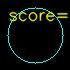

  frame=17 score=0.0000 usable=False points=0


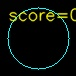

  frame=19 score=0.0000 usable=False points=0


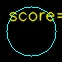

  frame=20 score=0.0000 usable=False points=0


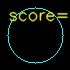

In [15]:
import os
import cv2
import math
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple, Optional, Any


def _enhance_ball_roi(roi_bgr: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6, 6))
    eq = clahe.apply(gray)
    den = cv2.bilateralFilter(eq, d=5, sigmaColor=35, sigmaSpace=35)
    blur = cv2.GaussianBlur(den, (0, 0), sigmaX=1.2)
    sharp = cv2.addWeighted(den, 1.7, blur, -0.7, 0)
    return sharp


def _extract_seam_contours(enhanced: np.ndarray, roi_radius_px: float) -> Tuple[np.ndarray, List[np.ndarray], float]:
    edges = cv2.Canny(enhanced, 70, 160)
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

    selected: List[np.ndarray] = []
    if roi_radius_px <= 1:
        return edges, selected, 0.0

    ball_perim = 2.0 * math.pi * roi_radius_px
    for c in contours:
        length = cv2.arcLength(c, closed=False)
        if length < 0.15 * ball_perim or length > 1.4 * ball_perim:
            continue
        x, y, w, h = cv2.boundingRect(c)
        if w < 4 or h < 4:
            continue
        area = float(cv2.contourArea(c) + 1e-6)
        thinness = (length * length) / (4.0 * math.pi * area)
        if thinness < 1.8:
            continue
        selected.append(c)

    edge_density = float((edges > 0).sum()) / float(edges.size + 1e-6)
    contour_bonus = min(len(selected) / 8.0, 1.0)
    score = 0.65 * edge_density + 0.35 * contour_bonus
    return edges, selected, float(score)


def estimate_seam_cues_v2(
    video_path: str,
    ball_df: pd.DataFrame,
    release_frames: List[int],
    out_dir: str,
    radius_scale: float = 1.25,
    min_score: float = 0.035
) -> Dict[int, Dict[str, Any]]:
    results: Dict[int, Dict[str, Any]] = {}
    cap = cv2.VideoCapture(video_path)
    base = os.path.basename(video_path)
    os.makedirs(out_dir, exist_ok=True)

    ball_df_idx = ball_df.set_index("frame", drop=False)

    for f in release_frames:
        entry: Dict[str, Any] = {
            "score": 0.0,
            "usable": False,
            "seam_points_sphere": np.zeros((0, 3), dtype=float),
            "qa_path": ""
        }
        try:
            if int(f) not in ball_df_idx.index:
                results[int(f)] = entry
                continue

            row = ball_df_idx.loc[int(f)]
            bx, by, br = float(row["ball_x"]), float(row["ball_y"]), float(row["ball_r"])
            if not np.isfinite(bx) or not np.isfinite(by) or not np.isfinite(br) or br < 2:
                results[int(f)] = entry
                continue

            cap.set(cv2.CAP_PROP_POS_FRAMES, int(f))
            ok, frame = cap.read()
            if not ok:
                results[int(f)] = entry
                continue

            r = max(int(br * radius_scale), 4)
            h, w = frame.shape[:2]
            x1 = max(int(bx) - r, 0); y1 = max(int(by) - r, 0)
            x2 = min(int(bx) + r, w - 1); y2 = min(int(by) + r, h - 1)
            if x2 <= x1 + 2 or y2 <= y1 + 2:
                results[int(f)] = entry
                continue

            roi = frame[y1:y2, x1:x2].copy()
            enh = _enhance_ball_roi(roi)
            _, contours, score = _extract_seam_contours(enh, roi_radius_px=float(r))

            seam_points: List[np.ndarray] = []
            qa = roi.copy()
            cv2.circle(qa, (int(bx - x1), int(by - y1)), int(br), (255, 255, 0), 1)

            for c in contours:
                cv2.drawContours(qa, [c], -1, (0, 255, 0), 1)
                pts = c.reshape(-1, 2)
                for px, py in pts:
                    fx = float(px + x1); fy = float(py + y1)
                    nx = (fx - bx) / br; ny = (fy - by) / br
                    rr2 = nx * nx + ny * ny
                    if rr2 <= 1.0:
                        nz = math.sqrt(max(0.0, 1.0 - rr2))
                        seam_points.append(np.array([nx, ny, nz], dtype=float))

            seam_arr = np.vstack(seam_points) if len(seam_points) > 0 else np.zeros((0, 3), dtype=float)
            usable = bool((score >= min_score) and (seam_arr.shape[0] >= 24))

            qa_path = os.path.join(out_dir, f"{base}_frame{int(f)}_seam_qa.jpg")
            cv2.putText(qa, f"score={score:.4f} usable={usable}", (8, 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 255), 1, cv2.LINE_AA)
            cv2.imwrite(qa_path, qa)

            entry["score"] = float(score)
            entry["usable"] = usable
            entry["seam_points_sphere"] = seam_arr
            entry["qa_path"] = qa_path
            results[int(f)] = entry

        except Exception as e:
            print(f"[Seam v2] frame={f} error: {e}")
            results[int(f)] = entry

    cap.release()
    return results


# Execute seam v2
seam_info = {}
for name in VIDEO_PATHS:
    frames = release_info[name]["frames"]
    seams_by_frame = estimate_seam_cues_v2(
        video_path=VIDEO_PATHS[name],
        ball_df=ball_results[name]["df"],
        release_frames=frames,
        out_dir=CONFIG["output_dir"],
        radius_scale=1.25,
        min_score=0.035
    )
    seam_info[name] = seams_by_frame
    print(f"[Seam v2] {name}:")
    for f in frames:
        info = seams_by_frame.get(int(f), {})
        pts_n = info.get("seam_points_sphere", np.zeros((0,3))).shape[0]
        print(f"  frame={f} score={info.get('score',0):.4f} usable={info.get('usable',False)} points={pts_n}")
        if info.get("qa_path"):
            from IPython.display import Image as DispImage, display
            display(DispImage(filename=info["qa_path"]))


# Section 6: Ball and Finger Geometry Reconstruction

Project fingertip coordinates onto a 3D sphere approximating the baseball.  Compute geodesic distances between finger contacts, thumb opposition angles, and a simple pressure proxy based on contact duration and acceleration.  If camera calibration is available, more accurate mapping may be substituted.

In [16]:
# =========================
# SECTION 6 — Ball + Finger Geometry Reconstruction (separate section)
# =========================
import math
import numpy as np
import pandas as pd
from typing import Dict, List, Optional, Tuple

FINGER_KEYS = ["thumb_tip", "index_tip", "middle_tip", "ring_tip", "pinky_tip"]

def nearest_valid_hand_frame(hand_df: pd.DataFrame, target_frame: int, max_offset: int = 6) -> Optional[int]:
    valid = hand_df.loc[
        hand_df["index_tip_x"].notna() & hand_df["index_tip_y"].notna(),
        "frame"
    ].astype(int).values
    if valid.size == 0:
        return None
    d = np.abs(valid - target_frame)
    i = int(np.argmin(d))
    return int(valid[i]) if int(d[i]) <= max_offset else None

def project_fingers_to_sphere_v2(
    hand_df: pd.DataFrame,
    ball_df: pd.DataFrame,
    release_frames: List[int],
    max_hand_offset: int = 6,
    contact_mul: float = 1.35
) -> Dict[int, Dict[str, Optional[np.ndarray]]]:
    """
    For each release frame:
    - use nearest valid hand frame (within max_hand_offset),
    - map fingertips near ball to sphere surface.
    """
    out: Dict[int, Dict[str, Optional[np.ndarray]]] = {}
    hand_lookup = hand_df.set_index("frame")
    ball_lookup = ball_df.set_index("frame")

    for rf in release_frames:
        record: Dict[str, Optional[np.ndarray]] = {k: None for k in FINGER_KEYS}
        record["_source_hand_frame"] = None
        record["_source_ball_frame"] = rf

        if rf not in ball_lookup.index:
            out[rf] = record
            continue

        rb = ball_lookup.loc[rf]
        bx, by, br = rb["ball_x"], rb["ball_y"], rb["ball_r"]
        if pd.isna(bx) or pd.isna(by) or pd.isna(br) or float(br) <= 0:
            out[rf] = record
            continue

        hf = nearest_valid_hand_frame(hand_df, target_frame=rf, max_offset=max_hand_offset)
        if hf is None or hf not in hand_lookup.index:
            out[rf] = record
            continue

        rh = hand_lookup.loc[hf]
        record["_source_hand_frame"] = hf

        for fk in FINGER_KEYS:
            x = rh.get(f"{fk}_x", np.nan)
            y = rh.get(f"{fk}_y", np.nan)
            if pd.isna(x) or pd.isna(y):
                continue

            dist = float(np.hypot(float(x) - float(bx), float(y) - float(by)))
            if dist > contact_mul * float(br):
                continue

            dx = (float(x) - float(bx)) / float(br)
            dy = (float(y) - float(by)) / float(br)
            rho2 = dx * dx + dy * dy
            if rho2 > 1.0:
                s = 1.0 / math.sqrt(rho2)
                dx *= s
                dy *= s
                rho2 = 1.0
            dz = math.sqrt(max(0.0, 1.0 - rho2))
            record[fk] = np.array([dx, dy, dz], dtype=float)

        out[rf] = record

    return out

def geodesic_distance(p1: Optional[np.ndarray], p2: Optional[np.ndarray], r: float = 1.0) -> Optional[float]:
    if p1 is None or p2 is None:
        return None
    c = float(np.dot(p1, p2) / (r * r))
    c = max(-1.0, min(1.0, c))
    return float(math.acos(c) * r)

def geometry_features_from_frame(points: Dict[str, Optional[np.ndarray]]) -> Dict[str, Optional[float]]:
    pairs = [
        ("thumb_tip", "index_tip"),
        ("index_tip", "middle_tip"),
        ("middle_tip", "ring_tip"),
        ("ring_tip", "pinky_tip"),
        ("thumb_tip", "pinky_tip"),
    ]
    feats: Dict[str, Optional[float]] = {}
    for a, b in pairs:
        feats[f"{a}_to_{b}_dist"] = geodesic_distance(points.get(a), points.get(b), r=1.0)

    th = points.get("thumb_tip")
    ix = points.get("index_tip")
    md = points.get("middle_tip")
    if th is None or ix is None or md is None:
        feats["thumb_opposition_deg"] = None
    else:
        v1 = ix - th
        v2 = md - th
        denom = float(np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
        c = float(np.dot(v1, v2) / denom)
        c = max(-1.0, min(1.0, c))
        feats["thumb_opposition_deg"] = float(np.degrees(np.arccos(c)))

    feats["n_contact_fingers"] = int(sum(points.get(k) is not None for k in FINGER_KEYS))
    return feats

def compute_pressure_proxy_v2(
    hand_df: pd.DataFrame,
    ball_df: pd.DataFrame,
    release_frame: Optional[int],
    fps: float
) -> float:
    """
    Heuristic proxy only: contact duration * release speed.
    Explicitly not true force/pressure.
    """
    if release_frame is None or np.isnan(release_frame):
        return 0.0

    df = hand_df.merge(ball_df, on="frame", how="inner").copy()
    if df.empty:
        return 0.0

    df["hand_valid"] = df["index_tip_x"].notna() & df["index_tip_y"].notna()
    df["ball_valid"] = df["ball_x"].notna() & df["ball_y"].notna() & df["ball_r"].notna()
    df = df[df["hand_valid"] & df["ball_valid"]].copy()
    if df.empty:
        return 0.0

    df["dist"] = np.hypot(df["index_tip_x"] - df["ball_x"], df["index_tip_y"] - df["ball_y"])
    df["contact"] = df["dist"] <= (1.35 * df["ball_r"])
    df["speed"] = np.hypot(df["ball_x"].diff(), df["ball_y"].diff()).fillna(0.0) * fps

    pre = df[df["frame"] <= int(release_frame)]
    if pre.empty:
        return 0.0

    contact_duration_s = float(pre["contact"].sum()) / max(fps, 1e-6)
    rel_idx = (pre["frame"] - int(release_frame)).abs().idxmin()
    release_speed = float(pre.loc[rel_idx, "speed"])

    return float(contact_duration_s * release_speed)

# run Section 6
geometry_info: Dict[str, pd.DataFrame] = {}
sphere_points_info: Dict[str, Dict[int, Dict[str, Optional[np.ndarray]]]] = {}
pressure_proxy_info: Dict[str, float] = {}

for name in VIDEO_PATHS:
    release_frames = release_info[name]["frames"]
    hand_df = hand_results[name]["df"]
    ball_df = ball_results[name].get("df_clean", ball_results[name]["df"])

    sp = project_fingers_to_sphere_v2(hand_df, ball_df, release_frames, max_hand_offset=6, contact_mul=1.35)
    sphere_points_info[name] = sp

    rows = []
    for f in release_frames:
        pts = sp.get(f, {})
        feat = geometry_features_from_frame(pts)
        feat["video_id"] = name
        feat["frame"] = f
        feat["source_hand_frame"] = pts.get("_source_hand_frame", None)
        feat["source_ball_frame"] = pts.get("_source_ball_frame", None)
        rows.append(feat)

    geom_df = pd.DataFrame(rows)
    geometry_info[name] = geom_df

    rel_f = release_frames[0] if release_frames else None
    pressure_proxy = compute_pressure_proxy_v2(hand_df, ball_df, rel_f, fps=float(VIDEO_METADATA[name]["fps"]))
    pressure_proxy_info[name] = pressure_proxy

    out_csv = os.path.join(CONFIG["output_dir"], f"{name}_geometry_features_v2.csv")
    geom_df.to_csv(out_csv, index=False)
    print(f"\n[Section 6] {name}")
    display(geom_df)
    print(f"Pressure proxy (heuristic) = {pressure_proxy:.4f}")



[Section 6] 96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov


,thumb_tip_to_index_tip_dist,index_tip_to_middle_tip_dist,middle_tip_to_ring_tip_dist,ring_tip_to_pinky_tip_dist,thumb_tip_to_pinky_tip_dist,thumb_opposition_deg,n_contact_fingers,video_id,frame,source_hand_frame,source_ball_frame
0,0.609298,1.584428,NaN,NaN,NaN,50.448030,3,96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov,16,16,16
1,0.444178,0.372791,0.412930,NaN,NaN,18.907726,4,96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov,17,17,17
2,1.545178,0.101505,0.154589,0.574242,0.912302,3.104074,5,96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov,19,19,19
3,1.274011,0.134945,0.429198,0.767038,0.868107,6.489211,5,96742e0b-a7e7-447b-a6ae-bc3e4a3f15c3 (1).mov,20,20,20


Pressure proxy (heuristic) = 0.0000


# Section 7: Interactive 3D Visualization

Visualise the reconstructed baseball and fingertip contact points in 3D using Plotly.  The sphere represents the ball, and coloured markers denote the positions of each fingertip at the candidate release frames.  Interactive rotation and zoom enable detailed inspection.

In [17]:
# =========================
# SECTION 7 — Interactive 3D Visualization (separate section)
# =========================
import numpy as np
import plotly.graph_objects as go
from typing import Dict, List, Optional

def create_sphere_mesh(resolution: int = 64) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)
    uu, vv = np.meshgrid(u, v)
    x = np.cos(uu) * np.sin(vv)
    y = np.sin(uu) * np.sin(vv)
    z = np.cos(vv)
    return x, y, z

def build_canonical_seams(n: int = 500) -> tuple[np.ndarray, np.ndarray]:
    """
    Canonical two-seam-style visual curves on a unit sphere.
    (Visualization seam model, independent from image seam extraction quality.)
    """
    t = np.linspace(0, 2 * np.pi, n)
    lat = 0.33 * np.sin(2 * t)
    lon = t
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    seam_a = np.column_stack([x, y, z])
    seam_b = np.column_stack([-x, y, -z])  # antipodal mirrored seam
    return seam_a, seam_b

def visualize_grip_with_seams_anim(
    sphere_points_by_frame: Dict[int, Dict[str, Optional[np.ndarray]]],
    frames: List[int],
    title: str = "3D Baseball Grip + Seams"
) -> go.Figure:
    x, y, z = create_sphere_mesh(64)
    seam_a, seam_b = build_canonical_seams(500)

    fig = go.Figure()

    # ball
    fig.add_trace(go.Surface(
        x=x, y=y, z=z, opacity=0.45, colorscale="Greys", showscale=False, name="ball"
    ))

    # seams (always drawn)
    fig.add_trace(go.Scatter3d(
        x=seam_a[:, 0], y=seam_a[:, 1], z=seam_a[:, 2],
        mode="lines", line=dict(color="firebrick", width=6), name="seam_A"
    ))
    fig.add_trace(go.Scatter3d(
        x=seam_b[:, 0], y=seam_b[:, 1], z=seam_b[:, 2],
        mode="lines", line=dict(color="firebrick", width=6), name="seam_B"
    ))

    finger_colors = {
        "thumb_tip": "#d62728",
        "index_tip": "#1f77b4",
        "middle_tip": "#2ca02c",
        "ring_tip": "#ff7f0e",
        "pinky_tip": "#9467bd",
    }

    # trajectories
    for fk, color in finger_colors.items():
        xs, ys, zs = [], [], []
        for f in frames:
            p = sphere_points_by_frame.get(f, {}).get(fk)
            if p is None:
                xs.append(None); ys.append(None); zs.append(None)
            else:
                xs.append(float(p[0])); ys.append(float(p[1])); zs.append(float(p[2]))
        fig.add_trace(go.Scatter3d(
            x=xs, y=ys, z=zs, mode="lines+markers",
            marker=dict(size=3, color=color),
            line=dict(color=color, width=4),
            name=fk
        ))

    # animated current-frame markers
    marker_trace_idxs: List[int] = []
    for fk, color in finger_colors.items():
        fig.add_trace(go.Scatter3d(
            x=[None], y=[None], z=[None], mode="markers",
            marker=dict(size=9, color=color),
            name=f"{fk}_current",
            showlegend=False
        ))
        marker_trace_idxs.append(len(fig.data) - 1)

    anim_frames: List[go.Frame] = []
    for f in frames:
        data = []
        for fk in finger_colors:
            p = sphere_points_by_frame.get(f, {}).get(fk)
            if p is None:
                data.append(go.Scatter3d(x=[None], y=[None], z=[None]))
            else:
                data.append(go.Scatter3d(x=[float(p[0])], y=[float(p[1])], z=[float(p[2])]))
        anim_frames.append(go.Frame(name=str(f), data=data, traces=marker_trace_idxs))
    fig.frames = anim_frames

    steps = [
        dict(
            method="animate",
            args=[[str(f)], {"mode":"immediate", "frame":{"duration":0, "redraw":True}, "transition":{"duration":0}}],
            label=str(f)
        )
        for f in frames
    ]

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis=dict(range=[-1.2, 1.2]),
            yaxis=dict(range=[-1.2, 1.2]),
            zaxis=dict(range=[-1.2, 1.2]),
            aspectmode="cube"
        ),
        sliders=[dict(active=0, steps=steps, x=0.1, y=0.02, len=0.8)],
        updatemenus=[dict(
            type="buttons",
            x=0.02, y=0.02,
            buttons=[
                dict(label="Play", method="animate",
                     args=[None, {"frame":{"duration":250, "redraw":True}, "transition":{"duration":0}, "fromcurrent":True}]),
                dict(label="Pause", method="animate",
                     args=[[None], {"frame":{"duration":0, "redraw":False}, "mode":"immediate"}]),
            ]
        )]
    )
    return fig

# render per video
for name in VIDEO_PATHS:
    frames = release_info[name]["frames"]
    if not frames:
        print(f"[Section 7] No release frames for {name}")
        continue
    sp = sphere_points_info.get(name, {})
    fig = visualize_grip_with_seams_anim(sp, frames, title=f"3D Grip + Canonical Seams — {name}")
    fig.show()


# Section 8: Training Data Export

Aggregate the features extracted throughout the pipeline into a single training table. Each row corresponds to a pitch attempt and includes metadata, release metrics, grip geometry features, seam confidence, and a pressure proxy.  The dataset is exported in both CSV and JSONL formats for downstream model training.  Coverage statistics summarise the availability of usable seam frames.

In [ ]:

import json

def create_training_dataset(video_names: List[str]) -> pd.DataFrame:
    """Combine extracted metrics into a flat training dataset."""
    rows: List[Dict] = []
    for name in video_names:
        hand_df = hand_results[name]['df']
        ball_df = ball_results[name]['df']
        release_frames = release_info[name]['frames']
        seam_scores = seam_info[name]['scores']
        seam_usable = seam_info[name]['usable']
        geometry_feats = geometry_info[name]
        proxy_score = geometry_info.get(name + '_pressure_proxy', 0.0)
        for i, f in enumerate(release_frames):
            geom = next((g for g in geometry_feats if g['frame'] == f), {})
            row: Dict = {
                'video_id': name,
                'pitcher_id': None,
                'handedness': hand_df.iloc[0].get('handedness', 'Unknown'),
                'pitch_type': None,
                'release_frame': f,
                'ball_center_x': ball_df.loc[ball_df['frame'] == f, 'ball_x'].values[0] if not ball_df.loc[ball_df['frame'] == f].empty else None,
                'ball_center_y': ball_df.loc[ball_df['frame'] == f, 'ball_y'].values[0] if not ball_df.loc[ball_df['frame'] == f].empty else None,
                'ball_radius_px': ball_df.loc[ball_df['frame'] == f, 'ball_r'].values[0] if not ball_df.loc[ball_df['frame'] == f].empty else None,
                'seam_score': seam_scores[i] if seam_scores else None,
                'seam_usable': seam_usable[i] if seam_usable else False,
                'pressure_proxy': proxy_score
            }
            for key, val in geom.items():
                if key != 'frame':
                    row[key] = val
            rows.append(row)
    return pd.DataFrame(rows)

# Build and save training dataset
training_df = create_training_dataset(list(VIDEO_PATHS.keys()))
train_csv = os.path.join(CONFIG['output_dir'], 'training_data.csv')
training_df.to_csv(train_csv, index=False)
train_jsonl = os.path.join(CONFIG['output_dir'], 'training_data.jsonl')
with open(train_jsonl, 'w') as f:
    for _, row in training_df.iterrows():
        f.write(json.dumps(row.dropna().to_dict()) + "
")
print(f"Training data saved to {train_csv} and {train_jsonl}")
print(training_df[['video_id','seam_usable']].groupby('video_id').agg(['count','sum']))


# Section 9: Evaluation & Error Analysis

Summarise pipeline performance by computing detection rates for hands and the ball, missing frame counts, and seam cue yields.  Generate a gallery of low‑confidence frames to diagnose failure modes and suggest improvements.

In [ ]:

import matplotlib.pyplot as plt
from IPython.display import Image as DispImage, display

def evaluate_results(hand_df: pd.DataFrame, ball_df: pd.DataFrame, seam_scores: List[float], seam_usable: List[bool]) -> Dict[str, float]:
    """Compute detection rates, missing frame counts, and seam yield."""
    total_frames = len(hand_df)
    hand_detected = hand_df[[col for col in hand_df.columns if col.endswith('_x')]].notna().any(axis=1).sum()
    ball_detected = ball_df['ball_x'].notna().sum()
    detection_rate_hand = hand_detected / total_frames if total_frames else 0.0
    detection_rate_ball = ball_detected / total_frames if total_frames else 0.0
    missing_frames = total_frames - min(len(hand_df), len(ball_df))
    seam_yield = sum(seam_usable) / len(seam_usable) if seam_usable else 0.0
    return {
        'hand_detection_rate': detection_rate_hand,
        'ball_detection_rate': detection_rate_ball,
        'missing_frames': missing_frames,
        'seam_yield': seam_yield
    }

def create_failure_gallery(video_path: str, hand_df: pd.DataFrame, ball_df: pd.DataFrame, threshold: float = 0.25, max_imgs: int = 5) -> List[str]:
    """Save frames where either hand or ball detection confidence is low."""
    cap = cv2.VideoCapture(video_path)
    failure_paths: List[str] = []
    count = 0
    for i in range(min(len(hand_df), len(ball_df))):
        if count >= max_imgs:
            break
        row_h = hand_df.iloc[i]
        row_b = ball_df.iloc[i]
        # Determine low confidence for hand and ball
        hand_confs = [row_h[col] for col in row_h.index if col.endswith('_conf')]
        max_hand_conf = max(hand_confs) if hand_confs else 0.0
        low_hand = max_hand_conf < threshold
        low_ball = (row_b['ball_conf'] < threshold) if not pd.isna(row_b['ball_conf']) else True
        if low_hand or low_ball:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if ret:
                path = os.path.join(CONFIG['output_dir'], f"failure_{os.path.basename(video_path)}_{i:04d}.jpg")
                cv2.imwrite(path, frame)
                failure_paths.append(path)
                count += 1
    cap.release()
    return failure_paths

# Evaluate and create failure galleries for each video
evaluation_metrics: Dict[str, Dict] = {}
failure_galleries: Dict[str, List[str]] = {}
for name in VIDEO_PATHS:
    metrics = evaluate_results(hand_results[name]['df'], ball_results[name]['df'], seam_info[name]['scores'], seam_info[name]['usable'])
    evaluation_metrics[name] = metrics
    print(f"Evaluation metrics for {name}: {metrics}")
    failures = create_failure_gallery(VIDEO_PATHS[name], hand_results[name]['df'], ball_results[name]['df'], threshold=0.3, max_imgs=5)
    failure_galleries[name] = failures
    print(f"Failure frames saved for {name}: {failures}")


# Section 10: Migration Kit for VS Code

Write the core logic into separate Python modules for easier migration to a production environment.  A requirements file and README are generated to guide installation and provide TODO steps for converting the notebook into a web service with FastAPI and a React front‑end.

In [ ]:

import os

# Directory to store exported modules and documentation
module_dir = os.path.join(CONFIG['output_dir'], 'modules')
os.makedirs(module_dir, exist_ok=True)

# Module strings
packages = [
    "mediapipe",
    "ultralytics",
    "opencv-python-headless",
    "numpy",
    "pandas",
    "plotly",
    "scipy",
    "pillow",
    "pytesseract",
    "scikit-image",
    "tqdm"
]

io_utils_py = """
import os
import cv2
import numpy as np
from typing import Dict, List, Tuple
from google.colab import files
from PIL import Image
import pytesseract

def upload_videos() -> Dict[str, str]:
    uploaded = files.upload()
    video_paths: Dict[str, str] = {}
    for name, data in uploaded.items():
        path = os.path.join('/content', name)
        with open(path, 'wb') as f:
            f.write(data)
        video_paths[name] = path
    return video_paths

def extract_metadata(video_path: str) -> Dict[str, float]:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f'Cannot open video {video_path}')
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = frame_count / fps if fps > 0 else 0
    cap.release()
    return {
        'fps': fps,
        'width': width,
        'height': height,
        'duration_sec': duration,
        'frame_count': int(frame_count)
    }

def sample_frames(video_path: str, stride: int = 30, resize: Tuple[int, int] = None, max_frames: int = 150) -> List[np.ndarray]:
    frames: List[np.ndarray] = []
    cap = cv2.VideoCapture(video_path)
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % stride == 0:
            if resize:
                frame = cv2.resize(frame, resize)
            frames.append(frame)
            if len(frames) >= max_frames:
                break
        idx += 1
    cap.release()
    return frames

def save_sample_frames(frames: List[np.ndarray], prefix: str, out_dir: str) -> None:
    qa_dir = os.path.join(out_dir, f"{prefix}_qa_frames")
    os.makedirs(qa_dir, exist_ok=True)
    for i, frame in enumerate(frames):
        cv2.imwrite(os.path.join(qa_dir, f'frame_{i:04d}.jpg'), frame)

def parse_ocr_overlay(frame: np.ndarray, ocr_enabled: bool = False) -> Dict[str, str]:
    if not ocr_enabled:
        return {}
    text = pytesseract.image_to_string(Image.fromarray(frame))
    return {'overlay_text': text.strip()}
"""

hand_pipeline_py = """
import os
import numpy as np
import pandas as pd
import cv2
import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import HandLandmarker, HandLandmarkerOptions
from typing import Dict, Tuple, List

class HandLandmarkPipeline:
    """Detect and smooth hand landmarks using MediaPipe."""
    def __init__(self, config: Dict):
        self.config = config
        self.model_path = config.get('hand_model_path', 'hand_landmarker.task')
        if not os.path.exists(self.model_path):
            import urllib.request
            url = 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker_lite/float16/1/hand_landmarker_lite.task'
            urllib.request.urlretrieve(url, self.model_path)
        options = HandLandmarkerOptions(
            base_options=vision.BaseOptions(model_asset_path=self.model_path),
            num_hands=1,
            min_hand_detection_confidence=config.get('hand_conf_thresh', 0.5),
            min_hand_presence_confidence=config.get('hand_conf_thresh', 0.5),
            min_tracking_confidence=config.get('hand_conf_thresh', 0.5)
        )
        self.landmarker = HandLandmarker.create_from_options(options)
        self.smoothing_window = config.get('smoothing_window', 7)
        self.frame_resize = config.get('frame_resize', None)
        self.output_dir = config.get('output_dir', '.')

    def process_video(self, video_path: str, quick_test: bool = False) -> Tuple[pd.DataFrame, str]:
        cap = cv2.VideoCapture(video_path)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        resize = self.frame_resize
        out_w, out_h = (resize if resize else (width, height))
        overlay_path = os.path.join(self.output_dir, os.path.basename(video_path) + '_hand_overlay.mp4')
        writer = cv2.VideoWriter(overlay_path, cv2.VideoWriter_fourcc(*'mp4v'), fps or 30.0, (out_w, out_h))
        finger_keys = ['thumb_tip','index_tip','middle_tip','ring_tip','pinky_tip']
        deque_buffer: Dict[str, List[Tuple[float,float]]] = {k: [] for k in finger_keys}
        rows: List[Dict] = []
        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame_resized = cv2.resize(frame, (out_w, out_h)) if resize else frame
            rgb_frame = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            try:
                result = self.landmarker.detect(mp_image)
            except Exception:
                result = None
            row: Dict = {'frame': frame_idx}
            for fk in finger_keys:
                row[fk + '_x'] = None
                row[fk + '_y'] = None
                row[fk + '_conf'] = 0.0
            if result and result.hand_landmarks:
                hand_lm = result.hand_landmarks[0]
                handedness = result.handedness[0].category_name if result.handedness else 'Unknown'
                lm_idx_map = {'thumb_tip':4, 'index_tip':8, 'middle_tip':12, 'ring_tip':16, 'pinky_tip':20}
                for fk, idx in lm_idx_map.items():
                    lm = hand_lm[idx]
                    x_px = lm.x * out_w
                    y_px = lm.y * out_h
                    confidence = getattr(hand_lm[idx], 'presence', 1.0)
                    row[fk + '_x'] = x_px
                    row[fk + '_y'] = y_px
                    row[fk + '_conf'] = confidence
                    buf = deque_buffer[fk]
                    buf.append((x_px, y_px))
                    if len(buf) > self.smoothing_window:
                        buf.pop(0)
                    xs = [pt[0] for pt in buf]
                    ys = [pt[1] for pt in buf]
                    row[fk + '_x_smooth'] = float(np.mean(xs))
                    row[fk + '_y_smooth'] = float(np.mean(ys))
                row['handedness'] = handedness
            else:
                for fk in finger_keys:
                    buf = deque_buffer[fk]
                    buf.append((None, None))
                    if len(buf) > self.smoothing_window:
                        buf.pop(0)
                    xs = [pt[0] for pt in buf if pt[0] is not None]
                    ys = [pt[1] for pt in buf if pt[1] is not None]
                    row[fk + '_x_smooth'] = float(np.mean(xs)) if xs else None
                    row[fk + '_y_smooth'] = float(np.mean(ys)) if ys else None
                row['handedness'] = 'Unknown'
            rows.append(row)
            overlay_frame = frame_resized.copy()
            for fk in finger_keys:
                x_s = row.get(fk + '_x_smooth', None)
                y_s = row.get(fk + '_y_smooth', None)
                if x_s is not None and y_s is not None:
                    color = (0, 255, 0)
                    cv2.circle(overlay_frame, (int(x_s), int(y_s)), 5, color, -1)
                    cv2.putText(overlay_frame, fk.split('_')[0], (int(x_s)+5, int(y_s)-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
            writer.write(cv2.cvtColor(overlay_frame, cv2.COLOR_RGB2BGR))
            frame_idx += 1
            if quick_test and frame_idx >= self.config.get('quick_test_frames', 150):
                break
        cap.release()
        writer.release()
        df = pd.DataFrame(rows)
        csv_path = os.path.join(self.output_dir, os.path.basename(video_path) + '_hand_landmarks.csv')
        df.to_csv(csv_path, index=False)
        json_path = os.path.join(self.output_dir, os.path.basename(video_path) + '_hand_landmarks.json')
        df.to_json(json_path, orient='records', indent=2)
        return df, overlay_path
"""

ball_pipeline_py = """
import os
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
from typing import Dict, Tuple, List

class BallTracker:
    """Detect and track a baseball using YOLO with a Hough circle fallback."""
    def __init__(self, config: Dict):
        self.config = config
        self.model = YOLO('yolov8n.pt')
        self.class_id = 32
        self.conf_thres = config.get('ball_conf_thresh', 0.25)
        self.frame_resize = config.get('frame_resize', None)
        self.output_dir = config.get('output_dir', '.')

    def detect_hough(self, gray: np.ndarray):
        circles = cv2.HoughCircles(
            gray,
            cv2.HOUGH_GRADIENT,
            dp=1.2,
            minDist=20,
            param1=50,
            param2=30,
            minRadius=5,
            maxRadius=50
        )
        if circles is not None:
            circles = np.round(circles[0, :]).astype('int')
            return circles[0]
        return None

    def process_video(self, video_path: str, quick_test: bool = False) -> Tuple[pd.DataFrame, str]:
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        resize = self.frame_resize
        out_w, out_h = (resize if resize else (width, height))
        overlay_path = os.path.join(self.output_dir, os.path.basename(video_path) + '_ball_overlay.mp4')
        writer = cv2.VideoWriter(overlay_path, cv2.VideoWriter_fourcc(*'mp4v'), fps or 30.0, (out_w, out_h))
        rows: List[Dict] = []
        trail_points: List[Tuple[int,int]] = []
        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame_resized = cv2.resize(frame, (out_w, out_h)) if resize else frame.copy()
            results = self.model(frame_resized, verbose=False)
            detections = results[0].boxes if results and len(results) > 0 else None
            ball_x = ball_y = ball_r = None
            ball_conf = 0.0
            if detections is not None and len(detections) > 0:
                for det in detections:
                    if int(det.cls[0]) == self.class_id and float(det.conf[0]) >= self.conf_thres:
                        x1, y1, x2, y2 = det.xyxy[0].cpu().numpy()
                        ball_x = (x1 + x2) / 2
                        ball_y = (y1 + y2) / 2
                        ball_r = max((x2 - x1), (y2 - y1)) / 2
                        ball_conf = float(det.conf[0])
                        break
            if ball_x is None:
                gray = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2GRAY)
                gray = cv2.medianBlur(gray, 5)
                circle = self.detect_hough(gray)
                if circle is not None:
                    ball_x, ball_y, ball_r = circle
                    ball_conf = 0.5
            rows.append({
                'frame': frame_idx,
                'ball_x': float(ball_x) if ball_x is not None else None,
                'ball_y': float(ball_y) if ball_y is not None else None,
                'ball_r': float(ball_r) if ball_r is not None else None,
                'ball_conf': ball_conf
            })
            overlay = frame_resized.copy()
            if ball_x is not None and ball_y is not None and ball_r is not None:
                center = (int(ball_x), int(ball_y))
                radius = int(ball_r)
                cv2.circle(overlay, center, radius, (0, 0, 255), 2)
                trail_points.append(center)
            for i in range(1, len(trail_points)):
                if trail_points[i-1] and trail_points[i]:
                    cv2.line(overlay, trail_points[i-1], trail_points[i], (255, 0, 0), 2)
            writer.write(overlay)
            frame_idx += 1
            if quick_test and frame_idx >= self.config.get('quick_test_frames', 150):
                break
        cap.release()
        writer.release()
        df = pd.DataFrame(rows)
        csv_path = os.path.join(self.output_dir, os.path.basename(video_path) + '_ball_tracking.csv')
        df.to_csv(csv_path, index=False)
        json_path = os.path.join(self.output_dir, os.path.basename(video_path) + '_ball_tracking.json')
        df.to_json(json_path, orient='records', indent=2)
        return df, overlay_path
"""

seam_pipeline_py = """
import cv2
import numpy as np
import pandas as pd
from typing import List, Tuple

def enhance_roi(roi: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    eq = clahe.apply(gray)
    blur = cv2.GaussianBlur(eq, (0,0), sigmaX=2)
    sharpened = cv2.addWeighted(eq, 1.5, blur, -0.5, 0)
    return sharpened

def seam_score(roi_enh: np.ndarray) -> float:
    edges = cv2.Canny(roi_enh, 100, 200)
    edge_sum = np.sum(edges > 0)
    area = roi_enh.size
    return edge_sum / area if area > 0 else 0.0

def estimate_seam_cues(video_path: str, ball_df: pd.DataFrame, frames: List[int], radius_scale: float = 1.5, threshold: float = 0.02) -> Tuple[List[float], List[bool]]:
    cap = cv2.VideoCapture(video_path)
    scores: List[float] = []
    usable: List[bool] = []
    for f in frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ret, frame = cap.read()
        if not ret:
            scores.append(0.0)
            usable.append(False)
            continue
        row = ball_df[ball_df['frame'] == f]
        if row.empty or pd.isna(row.iloc[0]['ball_x']):
            scores.append(0.0)
            usable.append(False)
            continue
        x = int(row.iloc[0]['ball_x'])
        y = int(row.iloc[0]['ball_y'])
        r = int(row.iloc[0]['ball_r'] * radius_scale)
        h, w, _ = frame.shape
        x1 = max(x - r, 0)
        y1 = max(y - r, 0)
        x2 = min(x + r, w - 1)
        y2 = min(y + r, h - 1)
        roi = frame[y1:y2, x1:x2]
        roi_enh = enhance_roi(roi)
        score = seam_score(roi_enh)
        scores.append(score)
        usable.append(score > threshold)
    cap.release()
    return scores, usable
"""

recon_pipeline_py = """
import numpy as np
import pandas as pd
import math
from typing import Dict, List

def project_fingers_to_sphere(hand_df: pd.DataFrame, ball_df: pd.DataFrame, frames: List[int]) -> Dict[int, Dict[str, np.ndarray]]:
    result: Dict[int, Dict[str, np.ndarray]] = {}
    for f in frames:
        row_hand = hand_df[hand_df['frame'] == f]
        row_ball = ball_df[ball_df['frame'] == f]
        if row_hand.empty or row_ball.empty:
            continue
        bx = row_ball.iloc[0]['ball_x']
        by = row_ball.iloc[0]['ball_y']
        br = row_ball.iloc[0]['ball_r']
        if pd.isna(bx) or pd.isna(br):
            continue
        sphere_points: Dict[str, np.ndarray] = {}
        for fk in ['thumb_tip','index_tip','middle_tip','ring_tip','pinky_tip']:
            x = row_hand.iloc[0][fk + '_x_smooth']
            y = row_hand.iloc[0][fk + '_y_smooth']
            if pd.isna(x) or pd.isna(y):
                sphere_points[fk] = None
                continue
            dx = (x - bx) / br
            dy = (y - by) / br
            dist_sq = dx*dx + dy*dy
            if dist_sq > 1.0:
                factor = 1.0 / math.sqrt(dist_sq)
                dx *= factor
                dy *= factor
                dz = 0.0
            else:
                dz = math.sqrt(1.0 - dist_sq)
            sphere_points[fk] = np.array([dx, dy, dz])
        result[f] = sphere_points
    return result

def compute_geodesic_features(sphere_points: Dict[str, np.ndarray], radius: float = 1.0) -> Dict[str, float]:
    features: Dict[str, float] = {}
    pairs = [('thumb_tip','index_tip'), ('index_tip','middle_tip'), ('middle_tip','ring_tip'), ('ring_tip','pinky_tip'), ('thumb_tip','pinky_tip')]
    for a, b in pairs:
        p1 = sphere_points.get(a)
        p2 = sphere_points.get(b)
        key = f"{a}_to_{b}_dist"
        if p1 is None or p2 is None:
            features[key] = None
        else:
            cos_angle = np.clip(np.dot(p1, p2) / (radius*radius), -1.0, 1.0)
            angle = math.acos(cos_angle)
            features[key] = angle * radius
    thumb = sphere_points.get('thumb_tip')
    index = sphere_points.get('index_tip')
    middle = sphere_points.get('middle_tip')
    if thumb is not None and index is not None and middle is not None:
        v1 = index - thumb
        v2 = middle - thumb
        cos_ang = np.dot(v1, v2) / ((np.linalg.norm(v1) * np.linalg.norm(v2)) + 1e-6)
        angle = math.acos(np.clip(cos_ang, -1.0, 1.0))
        features['thumb_opposition_deg'] = math.degrees(angle)
    else:
        features['thumb_opposition_deg'] = None
    return features

def compute_pressure_proxy(hand_df: pd.DataFrame, ball_df: pd.DataFrame, release_frames: List[int], fps: float) -> float:
    contact_frames = 0
    for i in range(len(hand_df)):
        row_hand = hand_df.iloc[i]
        row_ball = ball_df.iloc[i] if i < len(ball_df) else None
        if row_ball is None or pd.isna(row_ball['ball_x']):
            continue
        dist = math.hypot(
            row_hand['index_tip_x_smooth'] - row_ball['ball_x'],
            row_hand['index_tip_y_smooth'] - row_ball['ball_y']
        )
        if dist < 2 * row_ball['ball_r']:
            contact_frames += 1
        if row_hand['frame'] in release_frames:
            break
    contact_duration = contact_frames / fps if fps > 0 else 0.0
    df_merged = pd.merge(hand_df, ball_df, on='frame', how='inner')
    if 'vel' in df_merged.columns and not df_merged.empty:
        acc = df_merged['vel'].iloc[release_frames[0]] if release_frames else 0.0
    else:
        acc = 0.0
    return contact_duration * acc
"""

viz_utils_py = """
import numpy as np
import plotly.graph_objects as go
from typing import Dict, List

def create_sphere_mesh(resolution: int = 30):
    theta = np.linspace(0, 2 * np.pi, resolution)
    phi = np.linspace(0, np.pi, resolution)
    theta, phi = np.meshgrid(theta, phi)
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    return x, y, z

def visualize_grip(sphere_points: Dict[int, Dict[str, np.ndarray]], frames: List[int]) -> go.Figure:
    x, y, z = create_sphere_mesh()
    fig = go.Figure()
    fig.add_trace(go.Surface(x=x, y=y, z=z, opacity=0.3, colorscale='Viridis', showscale=False))
    finger_colors = {
        'thumb_tip': 'red',
        'index_tip': 'blue',
        'middle_tip': 'green',
        'ring_tip': 'orange',
        'pinky_tip': 'purple'
    }
    for fk, color in finger_colors.items():
        xs = [sphere_points[f][fk][0] if sphere_points[f].get(fk) is not None else None for f in frames]
        ys = [sphere_points[f][fk][1] if sphere_points[f].get(fk) is not None else None for f in frames]
        zs = [sphere_points[f][fk][2] if sphere_points[f].get(fk) is not None else None for f in frames]
        fig.add_trace(go.Scatter3d(
            x=xs, y=ys, z=zs,
            mode='markers+lines',
            marker=dict(size=5, color=color),
            name=fk
        ))
    fig.update_layout(
        scene=dict(aspectmode='data'),
        title='3D Baseball Grip Visualization',
        legend=dict(x=0.0, y=1.0)
    )
    return fig
"""

# Write out modules
modules = {
    'io_utils.py': io_utils_py,
    'hand_pipeline.py': hand_pipeline_py,
    'ball_pipeline.py': ball_pipeline_py,
    'seam_pipeline.py': seam_pipeline_py,
    'recon_pipeline.py': recon_pipeline_py,
    'viz_utils.py': viz_utils_py
}
for fname, content in modules.items():
    with open(os.path.join(module_dir, fname), 'w') as fh:
        fh.write(content)

# Write requirements.txt
with open(os.path.join(module_dir, 'requirements.txt'), 'w') as f:
    f.write("
".join(packages))

# Write README.md
readme_content = """
# Pitch Grip Pipeline Modules

This directory contains Python modules extracted from the Colab prototype for baseball pitch grip analysis. Each module corresponds to a section of the notebook and is ready to be imported into other projects.

## Modules

- `io_utils.py`: Video I/O utilities including file upload, metadata extraction and frame sampling.
- `hand_pipeline.py`: Hand landmark detection and smoothing using MediaPipe.
- `ball_pipeline.py`: Baseball detection and tracking with YOLO and a Hough circle fallback.
- `seam_pipeline.py`: Seam cue estimation via ROI enhancement and edge heuristics.
- `recon_pipeline.py`: 3D projection of fingertips onto a sphere and computation of grip features.
- `viz_utils.py`: Helper functions to visualise the ball and finger contacts in 3D using Plotly.

## Installation

Install the required packages using the provided `requirements.txt` file:

```bash
pip install -r requirements.txt
```

## Usage

Import the modules into your Python project or Jupyter notebook and use the classes/functions as demonstrated in the Colab prototype. The modules are designed to be self‑contained and modular so that they can be integrated into a backend API or other applications.

## TODO

- Refactor the notebook into a FastAPI backend service.
- Build a React front‑end to interact with the API and visualise results.
- Add unit tests for all modules and integrate continuous integration.
"""
with open(os.path.join(module_dir, 'README.md'), 'w') as f:
    f.write(readme_content)

print(f"Modules and migration kit written to {module_dir}")
